# **Install**

In [ ]:
!pip install timm albumentations opencv-python seaborn

# Import library-library yang diperlukan
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

import timm  # library untuk model-model vision terbaru, termasuk Swin Transformer

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

# Tentukan device (GPU jika tersedia)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device yang digunakan:", device)

Device yang digunakan: cuda


# **Konek Drive dan Ekstrak Dataset**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import zipfile
# Path ke file ZIP
dataset_path = '/content/drive/MyDrive/pokemon/pokemon-cards.zip'
extract_path = '/content/sample_data/pokemon/'

# Mengekstrak file ZIP
with zipfile.ZipFile(dataset_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# Menampilkan daftar file yang diekstrak
extracted_files = os.listdir(extract_path)
print("File yang diekstrak:", extracted_files)

# Mencari file CSV dalam folder yang diekstrak
csv_files = [file for file in extracted_files if file.endswith('.csv')]

# Jika ada file CSV, baca ke dalam DataFrame
if csv_files:
    csv_path = os.path.join(extract_path, csv_files[0])  # Ambil file CSV pertama
    df = pd.read_csv(csv_path)
    print(df.head())  # Menampilkan 5 baris pertama
else:
    print("Tidak ada file CSV dalam ZIP.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
File yang diekstrak: ['test_labels.csv', 'test', 'train_labels.csv', 'train']
    id  label
0  374      0
1  375      0
2  376      0
3  377      0
4  378      0


# **Load Dataset**

In [ ]:
data_dir = '/content/sample_data/pokemon/'
train_dir = os.path.join(data_dir, 'train')
test_dir  = os.path.join(data_dir, 'test')

train_csv_path = os.path.join(data_dir, 'train_labels.csv')
test_csv_path  = os.path.join(data_dir, 'test_labels.csv')

# Cek file yang ada
print("Isi folder dataset:", os.listdir(data_dir))

Isi folder dataset: ['test_labels.csv', 'test', 'train_labels.csv', 'train']


# **EDA**

Contoh data pada train_labels.csv:
   id  label
0   1      0
1   2      0
2   3      0
3   4      0
4   5      0

Distribusi label pada data training:
label
1    250
0    123
Name: count, dtype: int64


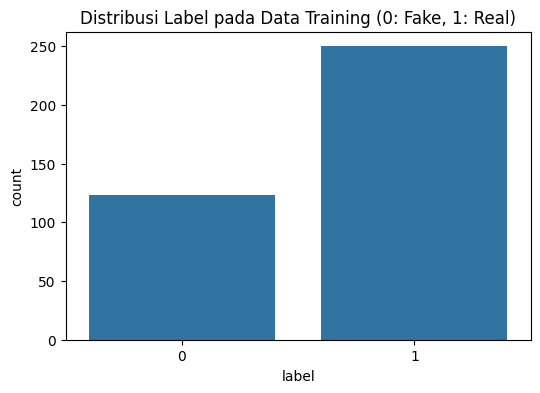

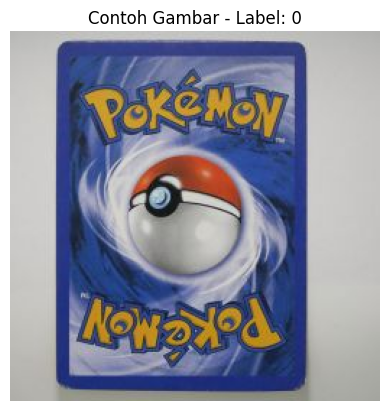

In [ ]:
# Baca file CSV label
train_df = pd.read_csv(train_csv_path)
test_df  = pd.read_csv(test_csv_path)

print("Contoh data pada train_labels.csv:")
print(train_df.head())

# Asumsikan kolom CSV: "id" dan "label" (0: Fake, 1: Real)
print("\nDistribusi label pada data training:")
print(train_df['label'].value_counts())

# Visualisasi distribusi label
plt.figure(figsize=(6,4))
sns.countplot(x='label', data=train_df)
plt.title("Distribusi Label pada Data Training (0: Fake, 1: Real)")
plt.show()

# Tampilkan contoh gambar dari data training
# Perhatikan bahwa file gambar diasumsikan bernama: id (dengan 5 digit, misal "00374") + ".JPG"
sample_id = str(train_df.iloc[0]['id'])
sample_img_path = os.path.join(train_dir, sample_id + ".JPG")
sample_img = cv2.imread(sample_img_path)
if sample_img is None:
    print("Gambar tidak ditemukan:", sample_img_path)
else:
    sample_img = cv2.cvtColor(sample_img, cv2.COLOR_BGR2RGB)
    plt.imshow(sample_img)
    plt.title(f"Contoh Gambar - Label: {train_df.iloc[0]['label']}")
    plt.axis("off")
    plt.show()


# **Membuat Custom Dataset Class**

In [ ]:
class PokemonDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        """ df (pd.DataFrame): Dataframe yang berisi kolom "id" dan "label" img_dir (str): Folder yang menyimpan gambartransform: Transformasi gambar (data augmentation/normalisasi)
        """
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_id = str(self.df.iloc[idx]['id'])
        label = self.df.iloc[idx]['label']
        img_path = os.path.join(self.img_dir, img_id + ".JPG")
        image = cv2.imread(img_path)
        if image is None:
            raise Exception(f"Image tidak ditemukan: {img_path}")
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        if self.transform:
            image = self.transform(image)
        return image, label


# **Data Augmentation and Preprocessing**

In [ ]:
# STEP 5: DEFINISIKAN TRANSFORMS (DATA AUGMENTATION & PREPROCESSING)
train_transforms = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((256,256)),
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_test_transforms = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# **Membagi Data Training Menjadi Training Dan Validasi**

In [ ]:
train_data, val_data = train_test_split(train_df, test_size=0.2,
                                          stratify=train_df['label'],
                                          random_state=42)

# Buat dataset dan DataLoader
train_dataset = PokemonDataset(train_data, train_dir, transform=train_transforms)
val_dataset   = PokemonDataset(val_data, train_dir, transform=val_test_transforms)

batch_size = 8

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

# **Buat Model Menggunakan Swin Transformer Dari Timm**

In [ ]:
model = timm.create_model('swin_tiny_patch4_window7_224', pretrained=True, num_classes=2)
model.to(device)

# Tampilkan ringkasan model (opsional)
print(model)

SwinTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
    (norm): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
  )
  (layers): Sequential(
    (0): SwinTransformerStage(
      (downsample): Identity()
      (blocks): Sequential(
        (0): SwinTransformerBlock(
          (norm1): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
          (attn): WindowAttention(
            (qkv): Linear(in_features=96, out_features=288, bias=True)
            (attn_drop): Dropout(p=0.0, inplace=False)
            (proj): Linear(in_features=96, out_features=96, bias=True)
            (proj_drop): Dropout(p=0.0, inplace=False)
            (softmax): Softmax(dim=-1)
          )
          (drop_path1): Identity()
          (norm2): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
          (mlp): Mlp(
            (fc1): Linear(in_features=96, out_features=384, bias=True)
            (act): GELU(approximate='none')
            (drop1): 

# **Loss Function, Optimizer, Dan Scheduler**

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-5, weight_decay=1e-5)

# penyesuaian learning rate tiap epoch
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)


# **Training Model**

In [ ]:
num_epochs = 20
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    running_corrects = 0
    total_samples = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        running_corrects += torch.sum(preds == labels.data)
        total_samples += labels.size(0)

    epoch_loss = running_loss / total_samples
    epoch_acc  = running_corrects.double() / total_samples
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc.item())

    # Validasi tiap epoch
    model.eval()
    val_running_loss = 0.0
    val_running_corrects = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            val_running_corrects += torch.sum(preds == labels.data)
            val_total += labels.size(0)

    val_epoch_loss = val_running_loss / val_total
    val_epoch_acc  = val_running_corrects.double() / val_total
    val_losses.append(val_epoch_loss)
    val_accuracies.append(val_epoch_acc.item())

    scheduler.step()

    print(f"Epoch {epoch+1}/{num_epochs}:")
    print(f"   Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc:.4f}")
    print(f"   Val Loss:   {val_epoch_loss:.4f} | Val Acc:   {val_epoch_acc:.4f}")
    print("-"*40)

Epoch 1/20:
   Train Loss: 0.5982 | Train Acc: 0.6846
   Val Loss:   0.4889 | Val Acc:   0.8533
----------------------------------------
Epoch 2/20:
   Train Loss: 0.5234 | Train Acc: 0.7919
   Val Loss:   0.3140 | Val Acc:   0.9600
----------------------------------------
Epoch 3/20:
   Train Loss: 0.3598 | Train Acc: 0.8591
   Val Loss:   0.1325 | Val Acc:   0.9867
----------------------------------------
Epoch 4/20:
   Train Loss: 0.1909 | Train Acc: 0.9530
   Val Loss:   0.0641 | Val Acc:   0.9867
----------------------------------------
Epoch 5/20:
   Train Loss: 0.1532 | Train Acc: 0.9597
   Val Loss:   0.1022 | Val Acc:   0.9733
----------------------------------------
Epoch 6/20:
   Train Loss: 0.0890 | Train Acc: 0.9799
   Val Loss:   0.1259 | Val Acc:   0.9733
----------------------------------------
Epoch 7/20:
   Train Loss: 0.0776 | Train Acc: 0.9799
   Val Loss:   0.0694 | Val Acc:   0.9867
----------------------------------------
Epoch 8/20:
   Train Loss: 0.0838 | Train

# **Visualisasi History Training**

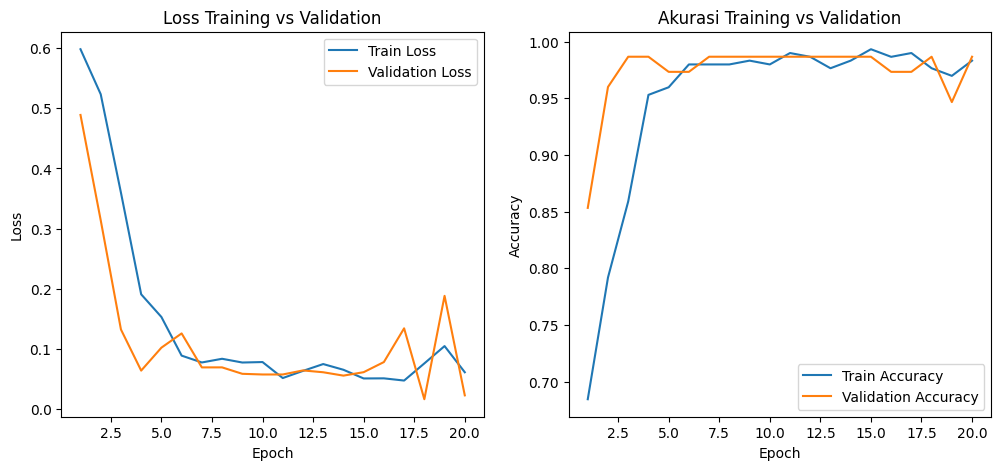

In [ ]:
epochs_range = range(1, num_epochs+1)
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(epochs_range, train_losses, label='Train Loss')
plt.plot(epochs_range, val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Training vs Validation')
plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs_range, train_accuracies, label='Train Accuracy')
plt.plot(epochs_range, val_accuracies, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Akurasi Training vs Validation')
plt.legend()

plt.show()

# **Evaluasi Model Pada Validation Set Dengan Confusion Matrix**

Classification Report (Validation):
              precision    recall  f1-score   support

        Fake       1.00      0.96      0.98        25
        Real       0.98      1.00      0.99        50

    accuracy                           0.99        75
   macro avg       0.99      0.98      0.98        75
weighted avg       0.99      0.99      0.99        75



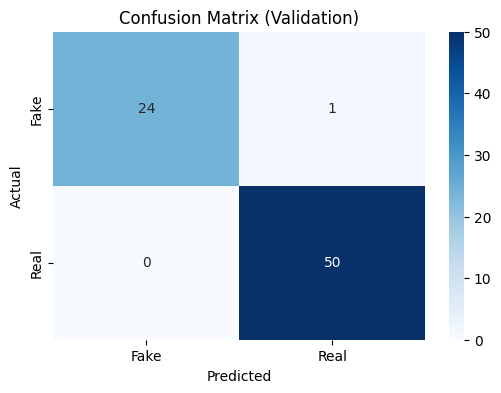

In [ ]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

print("Classification Report (Validation):")
print(classification_report(all_labels, all_preds, target_names=['Fake','Real']))

# Plot confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Fake','Real'], yticklabels=['Fake','Real'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Validation)')
plt.show()

# **Uji Coba Model Pada Test Set**

Classification Report (Test):
              precision    recall  f1-score   support

        Fake       1.00      0.93      0.96        28
        Real       0.96      1.00      0.98        50

    accuracy                           0.97        78
   macro avg       0.98      0.96      0.97        78
weighted avg       0.98      0.97      0.97        78



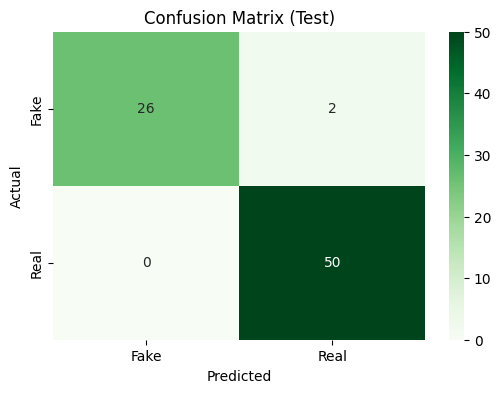

In [ ]:
test_dataset = PokemonDataset(test_df, test_dir, transform=val_test_transforms)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

model.eval()
test_preds = []
test_labels_list = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        test_preds.extend(preds.cpu().numpy())
        test_labels_list.extend(labels.numpy())

print("Classification Report (Test):")
print(classification_report(test_labels_list, test_preds, target_names=['Fake','Real']))

cm_test = confusion_matrix(test_labels_list, test_preds)
plt.figure(figsize=(6,4))
sns.heatmap(cm_test, annot=True, fmt="d", cmap="Greens",
            xticklabels=['Fake','Real'], yticklabels=['Fake','Real'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Test)')
plt.show()